In [1]:
#Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [2]:
#Load the dataset


df = pd.read_csv("dataset/PJME_hourly.csv")



df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [4]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df.dtypes

Datetime    datetime64[us]
PJME_MW            float64
dtype: object

In [8]:
#Rename columns

df = df.rename(columns={
    "Datetime": "timestamp",
    "PJME_MW": "demand"
})
df.head()

,timestamp,demand
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [10]:
df = df.sort_values("timestamp").reset_index(drop=True)
df.head()

,timestamp,demand
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0


In [11]:
print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

Start: 2002-01-01 01:00:00
End: 2018-08-03 00:00:00


In [12]:
#Check time intervals

time_diff = df["timestamp"].diff()

print(time_diff.value_counts().head(10))

timestamp
0 days 01:00:00    145331
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64


In [13]:
print("Most common interval:", time_diff.mode()[0])

Most common interval: 0 days 01:00:00


In [14]:
#Find gaps
gaps = df[time_diff > pd.Timedelta(hours=1)]

print("Number of gaps:", len(gaps))

Number of gaps: 30


In [15]:
gaps.head(10)

,timestamp,demand
2306,2002-04-07 04:00:00,24487.0
7176,2002-10-27 03:00:00,20605.0
11040,2003-04-06 04:00:00,22902.0
15910,2003-10-26 03:00:00,20641.0
19774,2004-04-04 04:00:00,23208.0
24812,2004-10-31 03:00:00,20585.0
28508,2005-04-03 04:00:00,23414.0
33546,2005-10-30 03:00:00,23302.0
37242,2006-04-02 04:00:00,20833.0
42280,2006-10-29 03:00:00,23310.0


In [16]:
#Check duplicate timestamps
duplicate_count = df["timestamp"].duplicated().sum()

print("Duplicate timestamps:", duplicate_count)

Duplicate timestamps: 4


In [17]:
duplicates = df[df["timestamp"].duplicated(keep=False)]

duplicates.head(20)

,timestamp,demand
112487,2014-11-02 02:00:00,23755.0
112488,2014-11-02 02:00:00,22935.0
121223,2015-11-01 02:00:00,21171.0
121224,2015-11-01 02:00:00,21567.0
130127,2016-11-06 02:00:00,20795.0
130128,2016-11-06 02:00:00,21692.0
138863,2017-11-05 02:00:00,21236.0
138864,2017-11-05 02:00:00,20666.0


In [18]:
#Check missing values
print(df.isnull().sum())

timestamp    0
demand       0
dtype: int64


In [19]:
#Percentage:

missing_percentage = df.isnull().mean() * 100

print(missing_percentage)

timestamp    0.0
demand       0.0
dtype: float64


In [20]:
print(df["demand"].isnull().sum())

0


In [21]:
#Basic statistical analysis
print("Mean:", df["demand"].mean())
print("Median:", df["demand"].median())
print("Minimum:", df["demand"].min())
print("Maximum:", df["demand"].max())
print("Standard Deviation:", df["demand"].std())

Mean: 32080.222830648156
Median: 31421.0
Minimum: 14544.0
Maximum: 62009.0
Standard Deviation: 6464.0121664127355


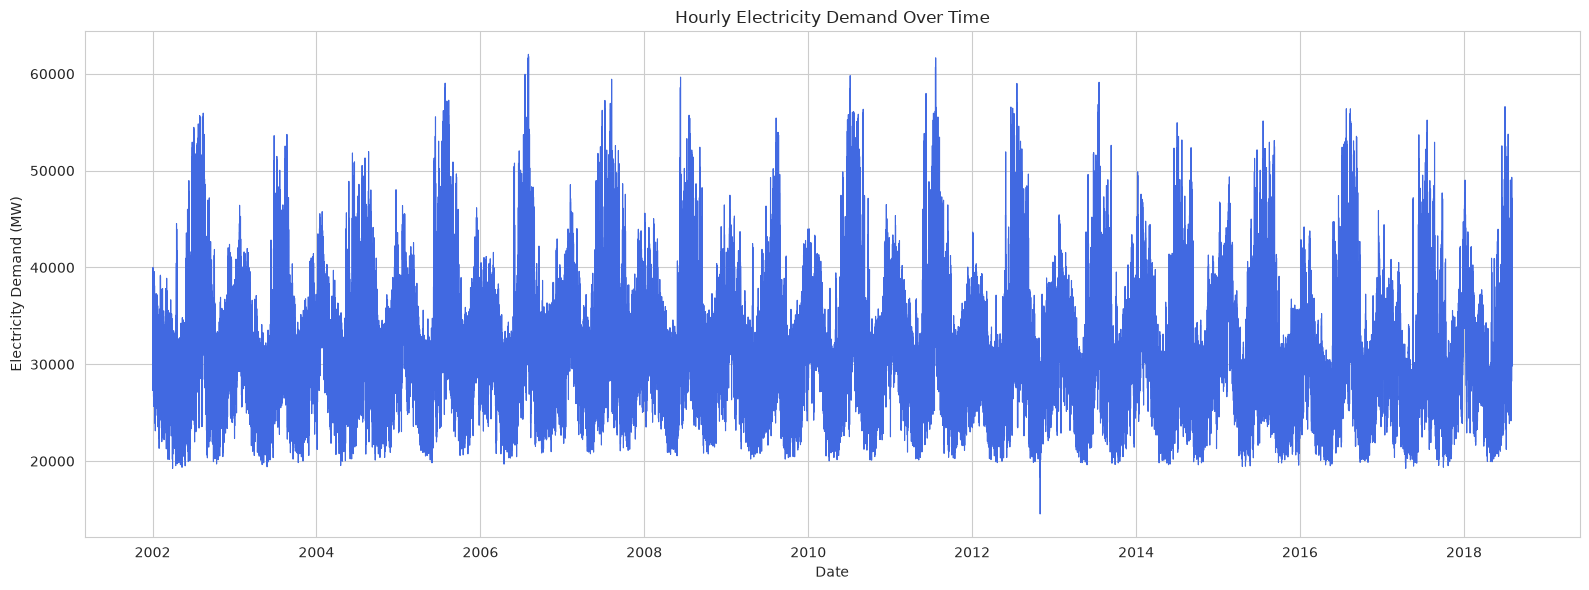

In [22]:
#Overall time-series plot
plt.figure(figsize=(16, 6))

plt.plot(
    df["timestamp"],
    df["demand"],
    color="royalblue",
    linewidth=0.8
)

plt.title("Hourly Electricity Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Electricity Demand (MW)")

plt.tight_layout()
plt.show()

In [25]:
#Daily consumption pattern

df["hour"] = df["timestamp"].dt.hour
hourly_pattern = df.groupby("hour")["demand"].mean()

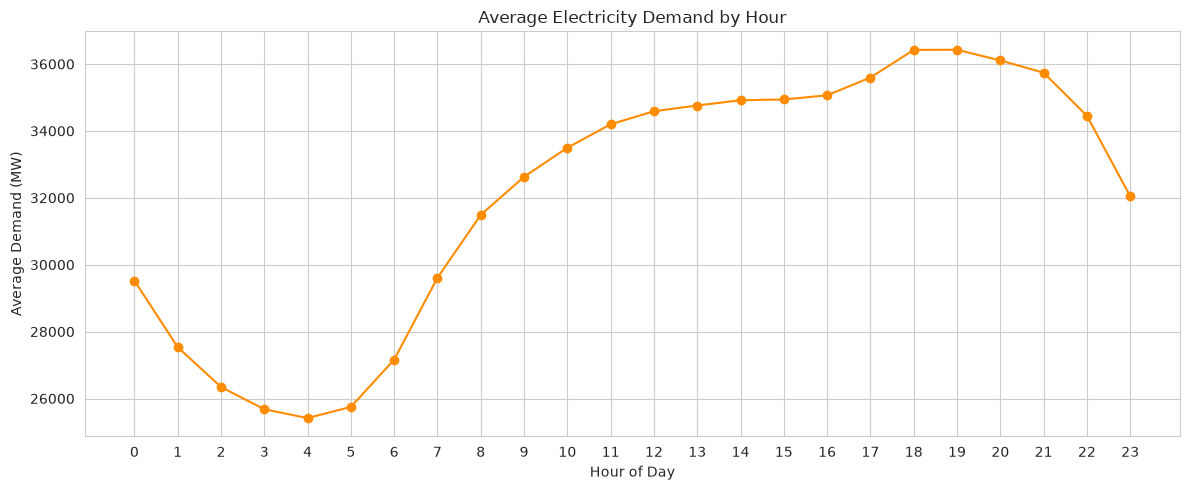

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_pattern.index,
    hourly_pattern.values,
    marker="o",
    color="darkorange"
)

plt.title("Average Electricity Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

In [29]:
#Weekly consumption pattern

df["day_of_week"] = df["timestamp"].dt.dayofweek
weekly_pattern = df.groupby("day_of_week")["demand"].mean()

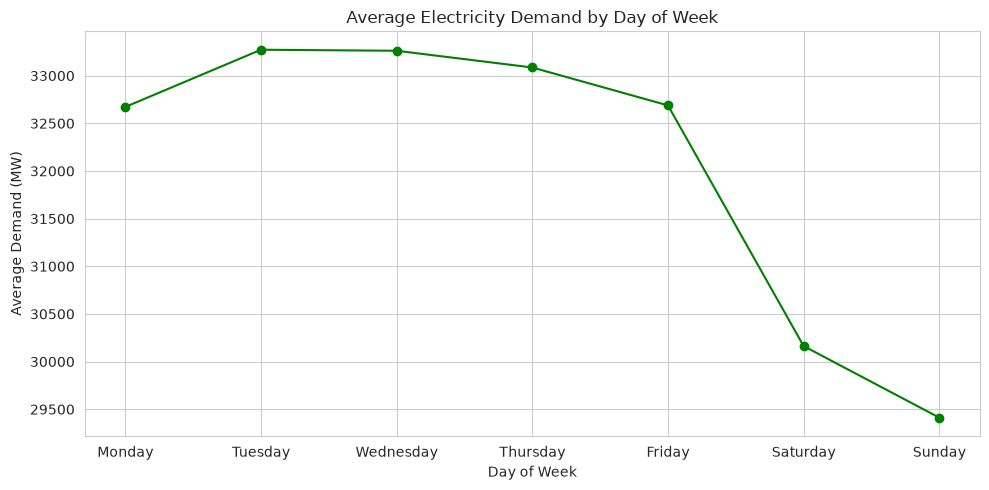

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(
    weekly_pattern.index,
    weekly_pattern.values,
    marker="o",
    color="green"
)

plt.title("Average Electricity Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand (MW)")

plt.xticks(
    range(7),
    ["Monday", "Tuesday", "Wednesday",
     "Thursday", "Friday", "Saturday", "Sunday"]
)

plt.tight_layout()
plt.show()

In [31]:
# Monthly trend
df["month"] = df["timestamp"].dt.month

In [32]:
monthly_pattern = df.groupby("month")["demand"].mean()

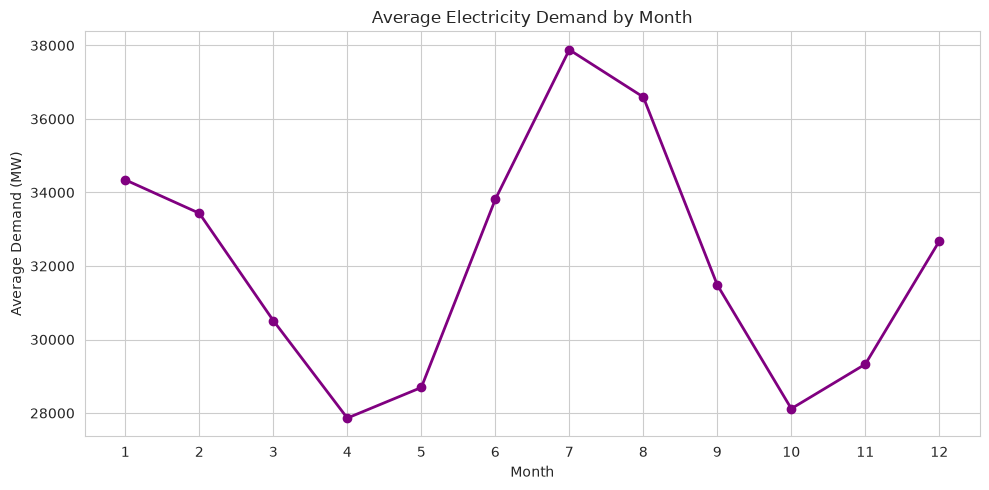

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_pattern.index,
    monthly_pattern.values,
    marker="o",
    linewidth=2,
    color="purple"
)

plt.title("Average Electricity Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand (MW)")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

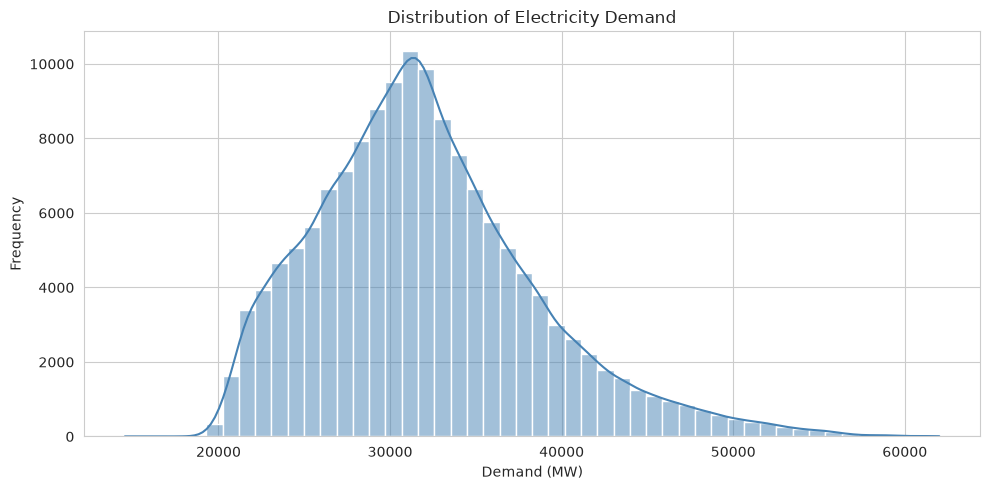

In [34]:
#Distribution of electricity demand
plt.figure(figsize=(10, 5))

sns.histplot(
    df["demand"],
    bins=50,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Electricity Demand")
plt.xlabel("Demand (MW)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

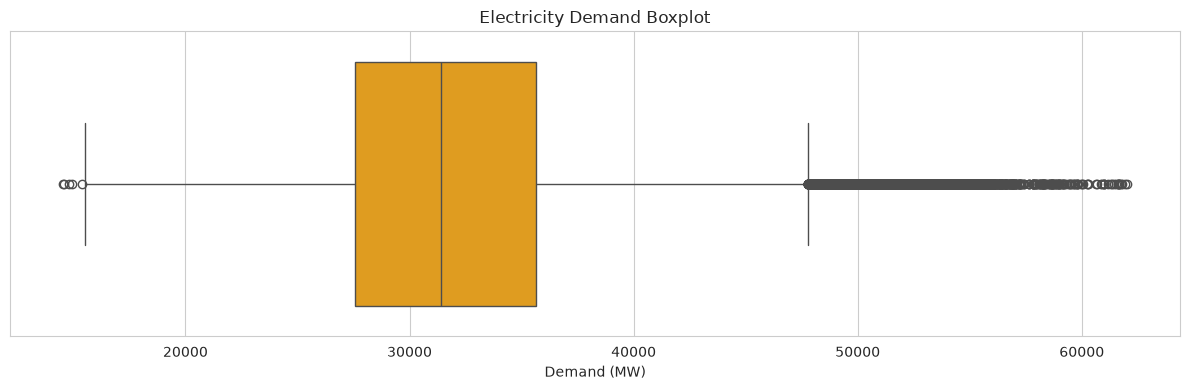

In [35]:
#Boxplot for abnormal values
plt.figure(figsize=(12, 4))

sns.boxplot(
    x=df["demand"],
    color="orange"
)

plt.title("Electricity Demand Boxplot")
plt.xlabel("Demand (MW)")

plt.tight_layout()
plt.show()

In [36]:
#Find extremely high/low demand
highest_demand = df.nlargest(10, "demand")

highest_demand[["timestamp", "demand"]]

,timestamp,demand
40183,2006-08-02 17:00:00,62009.0
40182,2006-08-02 16:00:00,61909.0
40207,2006-08-03 17:00:00,61796.0
40206,2006-08-03 16:00:00,61770.0
83730,2011-07-22 15:00:00,61646.0
40159,2006-08-01 17:00:00,61643.0
40181,2006-08-02 15:00:00,61641.0
40184,2006-08-02 18:00:00,61610.0
83731,2011-07-22 16:00:00,61608.0
83729,2011-07-22 14:00:00,61532.0


In [37]:
lowest_demand = df.nsmallest(10, "demand")

lowest_demand[["timestamp", "demand"]]

,timestamp,demand
94901,2012-10-30 04:00:00,14544.0
94900,2012-10-30 03:00:00,14586.0
94902,2012-10-30 05:00:00,14821.0
94899,2012-10-30 02:00:00,14955.0
94898,2012-10-30 01:00:00,15390.0
94903,2012-10-30 06:00:00,15526.0
94897,2012-10-30 00:00:00,15919.0
94904,2012-10-30 07:00:00,16688.0
94896,2012-10-29 23:00:00,17422.0
94905,2012-10-30 08:00:00,17734.0


In [38]:
#Daily average demand


daily_demand = (
    df.set_index("timestamp")["demand"]
    .resample("D")
    .mean()
)

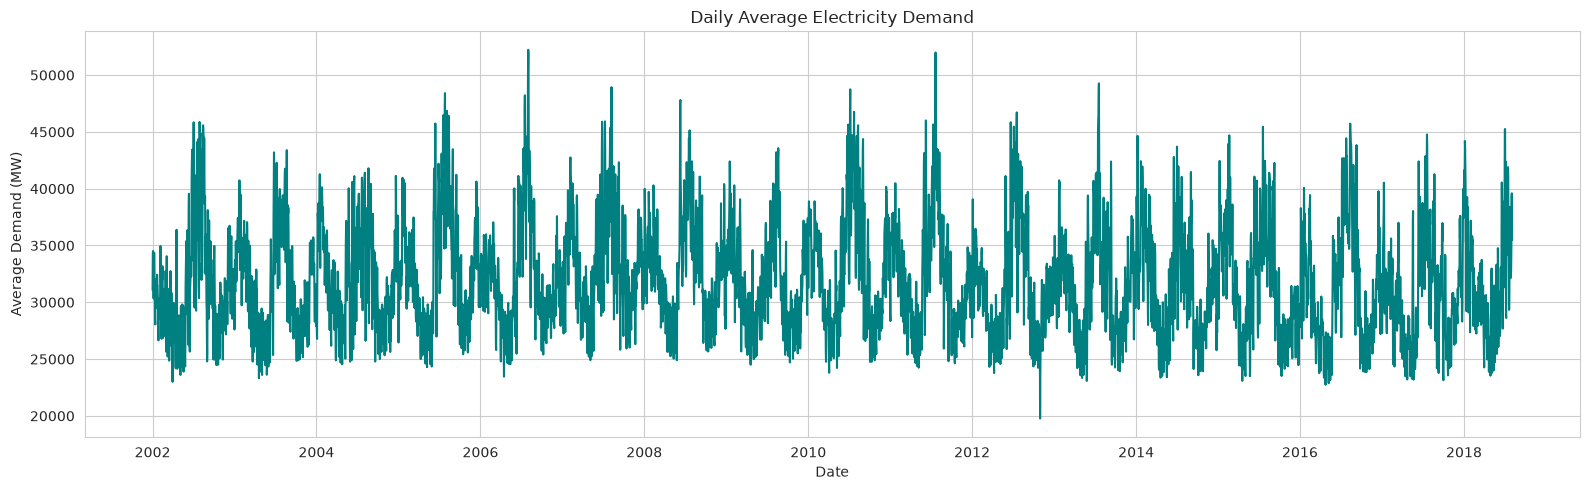

In [39]:
plt.figure(figsize=(16, 5))

plt.plot(
    daily_demand.index,
    daily_demand.values,
    color="teal"
)

plt.title("Daily Average Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Average Demand (MW)")

plt.tight_layout()
plt.show()

In [43]:
df["timestamp"].duplicated().sum()


np.int64(4)

In [44]:
duplicates = df[df["timestamp"].duplicated(keep=False)].sort_values("timestamp")

duplicates.head(20)

,timestamp,demand,hour,day_of_week,month
112487,2014-11-02 02:00:00,23755.0,2,6,11
112488,2014-11-02 02:00:00,22935.0,2,6,11
121223,2015-11-01 02:00:00,21171.0,2,6,11
121224,2015-11-01 02:00:00,21567.0,2,6,11
130127,2016-11-06 02:00:00,20795.0,2,6,11
130128,2016-11-06 02:00:00,21692.0,2,6,11
138863,2017-11-05 02:00:00,21236.0,2,6,11
138864,2017-11-05 02:00:00,20666.0,2,6,11


In [45]:
duplicates.groupby("timestamp")["demand"].agg(["count", "min", "max"])

,count,min,max
timestamp,,,
2014-11-02 02:00:00,2,22935.0,23755.0
2015-11-01 02:00:00,2,21171.0,21567.0
2016-11-06 02:00:00,2,20795.0,21692.0
2017-11-05 02:00:00,2,20666.0,21236.0


In [46]:
df = df.drop_duplicates(
    subset="timestamp",
    keep="first"
).reset_index(drop=True)

In [47]:
print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

Duplicate timestamps: 0


In [48]:
#Now check missing timestamps

df = df.sort_values("timestamp").reset_index(drop=True)

time_diff = df["timestamp"].diff()

missing_intervals = df[time_diff > pd.Timedelta(hours=1)]

print("Missing intervals:", len(missing_intervals))

Missing intervals: 30


In [49]:
missing_intervals[["timestamp"]].head(20)

,timestamp
2306,2002-04-07 04:00:00
7176,2002-10-27 03:00:00
11040,2003-04-06 04:00:00
15910,2003-10-26 03:00:00
19774,2004-04-04 04:00:00
24812,2004-10-31 03:00:00
28508,2005-04-03 04:00:00
33546,2005-10-30 03:00:00
37242,2006-04-02 04:00:00
42280,2006-10-29 03:00:00


In [50]:
hourly_series = (
    df.set_index("timestamp")["demand"]
    .asfreq("h")
)

In [51]:
hourly_series.isna().sum()

np.int64(30)

In [52]:
#Seasonal decomposition
hourly_series = (
    df.set_index("timestamp")["demand"]
    .asfreq("h")
)

In [53]:
hourly_series = hourly_series.interpolate()

In [54]:
decomposition = seasonal_decompose(
    hourly_series,
    model="additive",
    period=24
)

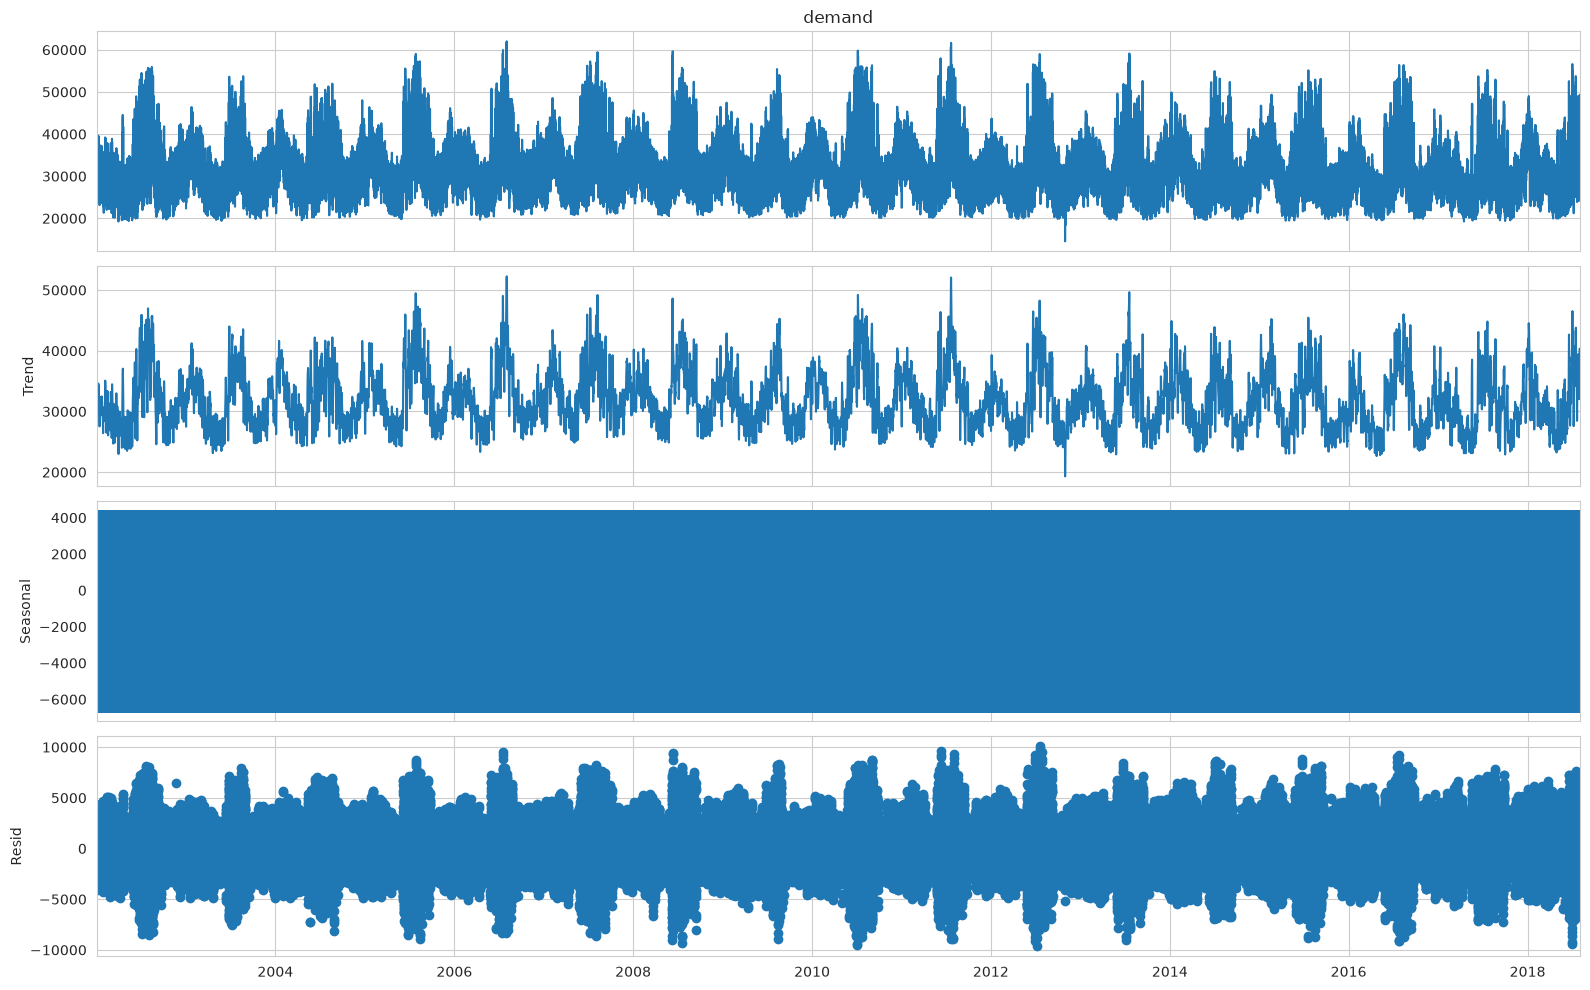

In [55]:
fig = decomposition.plot()

fig.set_size_inches(16, 10)

plt.tight_layout()
plt.show()

In [ ]:
decomposition.seasonal[:24].plot(figsize=(10,4))
plt.title("Daily Seasonal Pattern")
plt.show()

# Phase -02 Time-Series Preprocessing.

In [56]:
data = df.copy()

In [58]:
data["timestamp"] = pd.to_datetime(data["timestamp"])

In [59]:
data = data.sort_values("timestamp").reset_index(drop=True)

In [60]:
data = data.set_index("timestamp")

In [61]:
data.head()

,demand,hour,day_of_week,month
timestamp,,,,
2002-01-01 01:00:00,30393.0,1,1,1
2002-01-01 02:00:00,29265.0,2,1,1
2002-01-01 03:00:00,28357.0,3,1,1
2002-01-01 04:00:00,27899.0,4,1,1
2002-01-01 05:00:00,28057.0,5,1,1


In [62]:
data.tail()

,demand,hour,day_of_week,month
timestamp,,,,
2018-08-02 20:00:00,44057.0,20,3,8
2018-08-02 21:00:00,43256.0,21,3,8
2018-08-02 22:00:00,41552.0,22,3,8
2018-08-02 23:00:00,38500.0,23,3,8
2018-08-03 00:00:00,35486.0,0,4,8


In [63]:
#Create a continuous hourly index
full_index = pd.date_range(
    start=data.index.min(),
    end=data.index.max(),
    freq="h"
)

In [64]:
data = data.reindex(full_index)

In [65]:
data.index.name = "timestamp"

In [66]:
data.head()

,demand,hour,day_of_week,month
timestamp,,,,
2002-01-01 01:00:00,30393.0,1.0,1.0,1.0
2002-01-01 02:00:00,29265.0,2.0,1.0,1.0
2002-01-01 03:00:00,28357.0,3.0,1.0,1.0
2002-01-01 04:00:00,27899.0,4.0,1.0,1.0
2002-01-01 05:00:00,28057.0,5.0,1.0,1.0


In [67]:
#Check missing values
data.isnull().sum()

demand         30
hour           30
day_of_week    30
month          30
dtype: int64

In [68]:
data["demand"] = data["demand"].interpolate(
    method="time"
)

In [69]:
data["demand"].isnull().sum()

np.int64(0)

In [70]:
print(data.isnull().sum())

demand          0
hour           30
day_of_week    30
month          30
dtype: int64


In [71]:
print("Total missing values:", data.isnull().sum().sum())

Total missing values: 90


In [72]:
# Check duplicates again
print("Duplicate timestamps:", data.index.duplicated().sum())

Duplicate timestamps: 0


In [73]:
#Check hourly frequency
print(
    pd.infer_freq(data.index)
)

h


In [74]:
data["hour"] = data.index.hour
data["day"] = data.index.day
data["day_of_week"] = data.index.dayofweek

In [75]:
#Week

data["week"] = data.index.isocalendar().week.astype(int)

In [76]:
#Month
data["month"] = data.index.month
#Year
data["year"] = data.index.year

In [77]:
#Weekend

data["is_weekend"] = (
    data["day_of_week"] >= 5
).astype(int)

In [78]:
data[[
    "hour",
    "day_of_week",
    "month",
    "is_weekend"
]].head()

,hour,day_of_week,month,is_weekend
timestamp,,,,
2002-01-01 01:00:00,1,1,1,0
2002-01-01 02:00:00,2,1,1,0
2002-01-01 03:00:00,3,1,1,0
2002-01-01 04:00:00,4,1,1,0
2002-01-01 05:00:00,5,1,1,0


In [79]:
#Create lag features
data["lag_1"] = data["demand"].shift(1)

In [111]:
data["lag_24"] = data["demand"].shift(24)

In [ ]:
data["lag_48"] = data["demand"].shift(48)

In [81]:
data["lag_168"] = data["demand"].shift(168)

In [82]:
data["lag_24"] = data["demand"].shift(24)

In [83]:
#168-hour rolling mean
data["rolling_mean_168"] = (
    data["demand"]
    .rolling(window=168)
    .mean()
)

In [84]:
#Create rolling standard deviation
data["rolling_std_24"] = (
    data["demand"]
    .rolling(window=24)
    .std()
)

In [85]:
data["rolling_std_168"] = (
    data["demand"]
    .rolling(window=168)
    .std()
)

In [86]:
data["rolling_mean_24"] = (
    data["demand"]
    .shift(1)
    .rolling(24)
    .mean()
)

In [ ]:
data["rolling_std_24"] = (
    data["demand"]
    .shift(1)
    .rolling(24)
    .std()
)

In [87]:
data["rolling_mean_168"] = (
    data["demand"]
    .shift(1)
    .rolling(168)
    .mean()
)

data["rolling_std_168"] = (
    data["demand"]
    .shift(1)
    .rolling(168)
    .std()
)

In [88]:
data.isnull().sum()

demand                0
hour                  0
day_of_week           0
month                 0
day                   0
week                  0
year                  0
is_weekend            0
lag_1                 1
lag_48               48
lag_168             168
rolling_mean_24      24
rolling_mean_168    168
rolling_std_24       23
rolling_std_168     168
dtype: int64

In [89]:
data = data.dropna().copy()

In [90]:
data.isnull().sum().sum()

np.int64(0)

In [91]:
#Detect outliers
Q1 = data["demand"].quantile(0.25)
Q3 = data["demand"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: 15452.0
Upper bound: 47764.0


In [92]:
outliers = data[
    (data["demand"] < lower_bound) |
    (data["demand"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 3456


In [93]:
outliers[["demand"]].describe()

,demand
count,3456.000000
mean,51132.230903
std,3070.905702
min,14544.000000
25%,48972.500000
50%,50534.500000
75%,52757.500000
max,62009.000000


In [94]:
outliers.head(20)

,demand,hour,day_of_week,month,day,week,year,is_weekend,lag_1,lag_48,lag_168,rolling_mean_24,rolling_mean_168,rolling_std_24,rolling_std_168
timestamp,,,,,,,,,,,,,,,
2002-06-11 16:00:00,48426.0,16,1,6,11,24,2002,0,47476.0,30977.0,36930.0,36432.458333,32119.702381,7577.414802,7096.850555
2002-06-11 17:00:00,48968.0,17,1,6,11,24,2002,0,48426.0,32103.0,36993.0,36641.041667,32188.130952,7864.946479,7198.208687
2002-06-11 18:00:00,48565.0,18,1,6,11,24,2002,0,48968.0,33034.0,36658.0,36864.083333,32259.410714,8125.103504,7304.578357
2002-06-12 15:00:00,47852.0,15,2,6,12,24,2002,0,47411.0,42901.0,44615.0,40279.666667,33073.464286,7352.580882,7769.435102
2002-06-24 13:00:00,48937.0,13,0,6,24,26,2002,0,47140.0,37015.0,36303.0,36847.333333,33112.083333,6154.702352,6009.463566
2002-06-24 14:00:00,50207.0,14,0,6,24,26,2002,0,48937.0,37725.0,36811.0,37324.791667,33187.285714,6691.634437,6127.524959
2002-06-24 15:00:00,50783.0,15,0,6,24,26,2002,0,50207.0,38361.0,37037.0,37806.708333,33267.023810,7192.628644,6260.678098
2002-06-24 16:00:00,51148.0,16,0,6,24,26,2002,0,50783.0,38865.0,37299.0,38273.125000,33348.845238,7650.558165,6398.549169
2002-06-24 17:00:00,51137.0,17,0,6,24,26,2002,0,51148.0,39425.0,37214.0,38719.833333,33431.279762,8048.880508,6537.447912


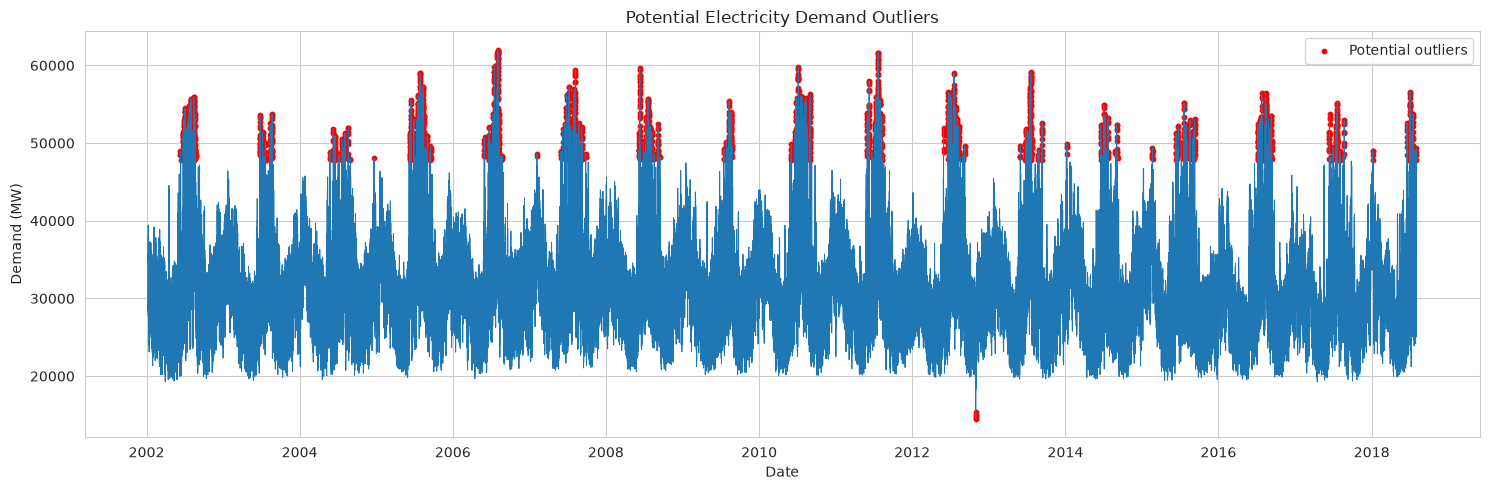

In [95]:
#Visualize outliers
plt.figure(figsize=(15, 5))

plt.plot(
    data.index,
    data["demand"],
    linewidth=0.7
)

plt.scatter(
    outliers.index,
    outliers["demand"],
    color="red",
    s=10,
    label="Potential outliers"
)

plt.title("Potential Electricity Demand Outliers")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()

plt.tight_layout()
plt.show()

In [97]:
#Final dataset check
print("Shape:", data.shape)
print()
print(data.head())

Shape: (145224, 15)

                      demand  hour  day_of_week  month  day  week  year  \
timestamp                                                                 
2002-01-08 01:00:00  29445.0     1            1      1    8     2  2002   
2002-01-08 02:00:00  28670.0     2            1      1    8     2  2002   
2002-01-08 03:00:00  28375.0     3            1      1    8     2  2002   
2002-01-08 04:00:00  28542.0     4            1      1    8     2  2002   
2002-01-08 05:00:00  29261.0     5            1      1    8     2  2002   

                     is_weekend    lag_1   lag_48  lag_168  rolling_mean_24  \
timestamp                                                                     
2002-01-08 01:00:00           0  31187.0  27100.0  30393.0     33452.583333   
2002-01-08 02:00:00           0  29445.0  26097.0  29265.0     33560.208333   
2002-01-08 03:00:00           0  28670.0  25793.0  28357.0     33672.458333   
2002-01-08 04:00:00           0  28375.0  25657.0  27899.0

In [98]:
import os

os.makedirs("../dataset/processed", exist_ok=True)

In [170]:
data.to_csv(
    "pjm_processed.csv"
)

# Phase-3 Exploratory Data Analysis

In [99]:
#Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_style("whitegrid")

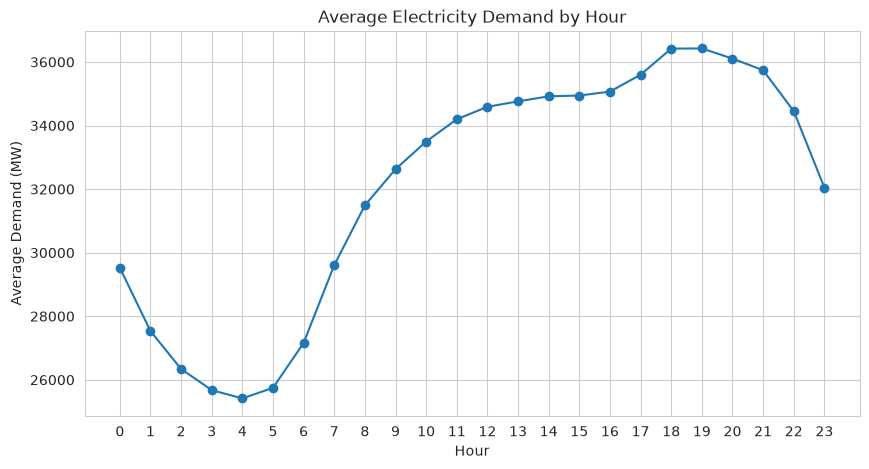

In [100]:
#Hourly demand profile
hourly_demand = data.groupby("hour")["demand"].mean()

plt.figure(figsize=(10,5))

plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker="o"
)

plt.title("Average Electricity Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(24))

plt.show()

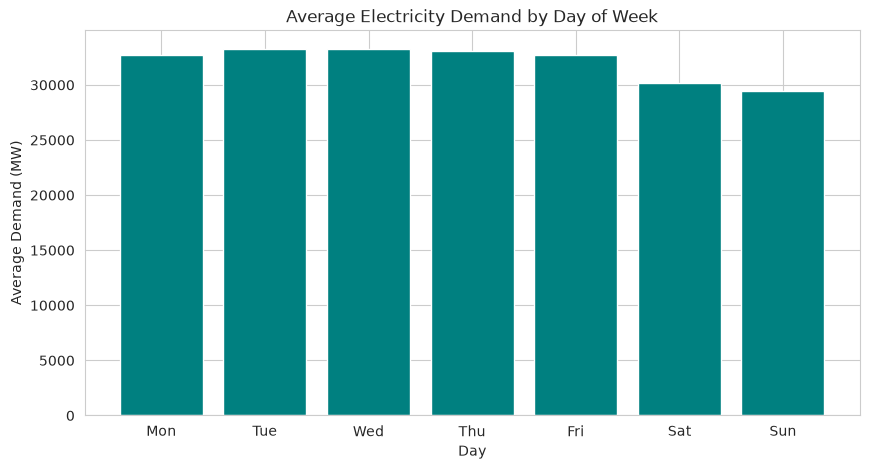

In [101]:
#Weekly demand pattern
weekly_demand = data.groupby("day_of_week")["demand"].mean()

plt.figure(figsize=(10,5))

plt.bar(
    weekly_demand.index,
    weekly_demand.values,
    color="teal"
)

plt.title("Average Electricity Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Demand (MW)")

plt.xticks(
    range(7),
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)

plt.show()

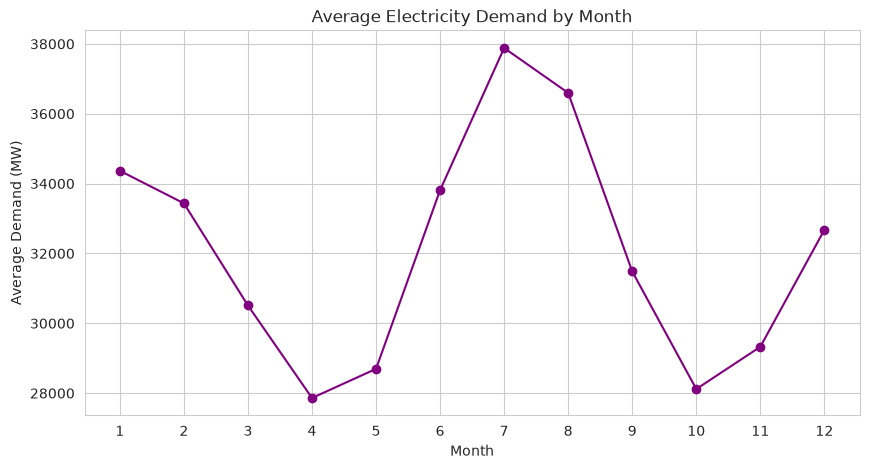

In [102]:
#Monthly / annual pattern
monthly_demand = data.groupby("month")["demand"].mean()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker="o",
    color="purple"
)

plt.title("Average Electricity Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand (MW)")
plt.xticks(range(1,13))

plt.show()

In [104]:
data["period"] = np.where(
    data["hour"].between(8, 20),
    "Peak",
    "Off-Peak"
)

In [105]:
peak_demand = data.groupby("period")["demand"].mean()

print(peak_demand)

period
Off-Peak    29021.995418
Peak        34664.622287
Name: demand, dtype: float64


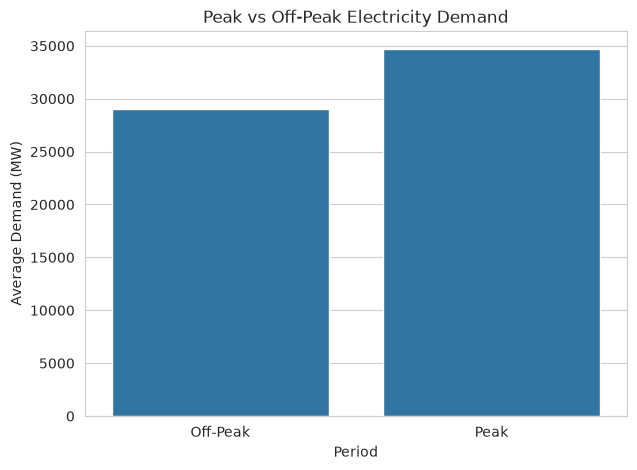

In [106]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=peak_demand.index,
    y=peak_demand.values
)

plt.title("Peak vs Off-Peak Electricity Demand")
plt.xlabel("Period")
plt.ylabel("Average Demand (MW)")

plt.show()

In [107]:
heatmap_data = data.pivot_table(
    values="demand",
    index="hour",
    columns="day_of_week",
    aggfunc="mean"
)

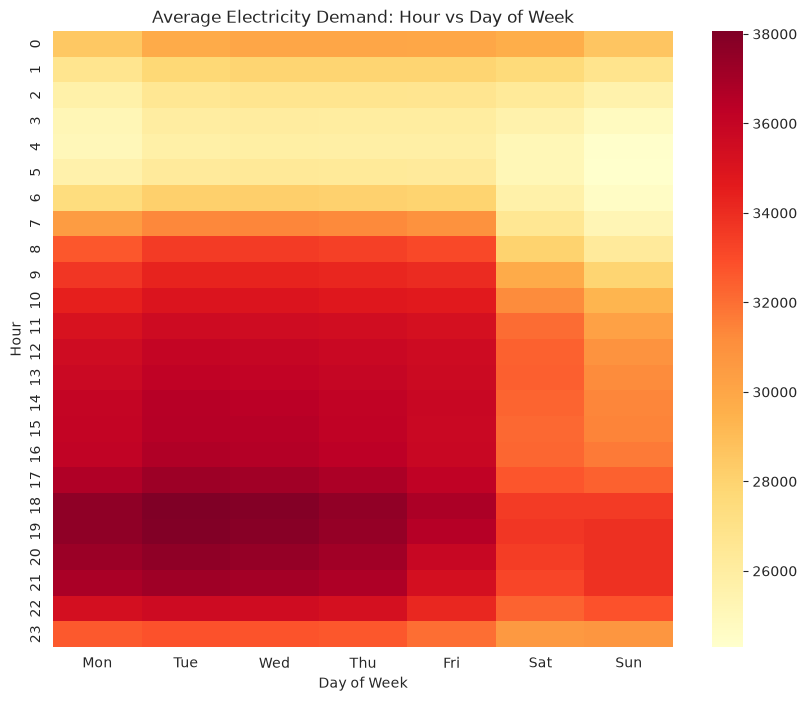

In [108]:
plt.figure(figsize=(10,8))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd"
)

plt.title("Average Electricity Demand: Hour vs Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Hour")

plt.xticks(
    np.arange(7) + 0.5,
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)

plt.show()

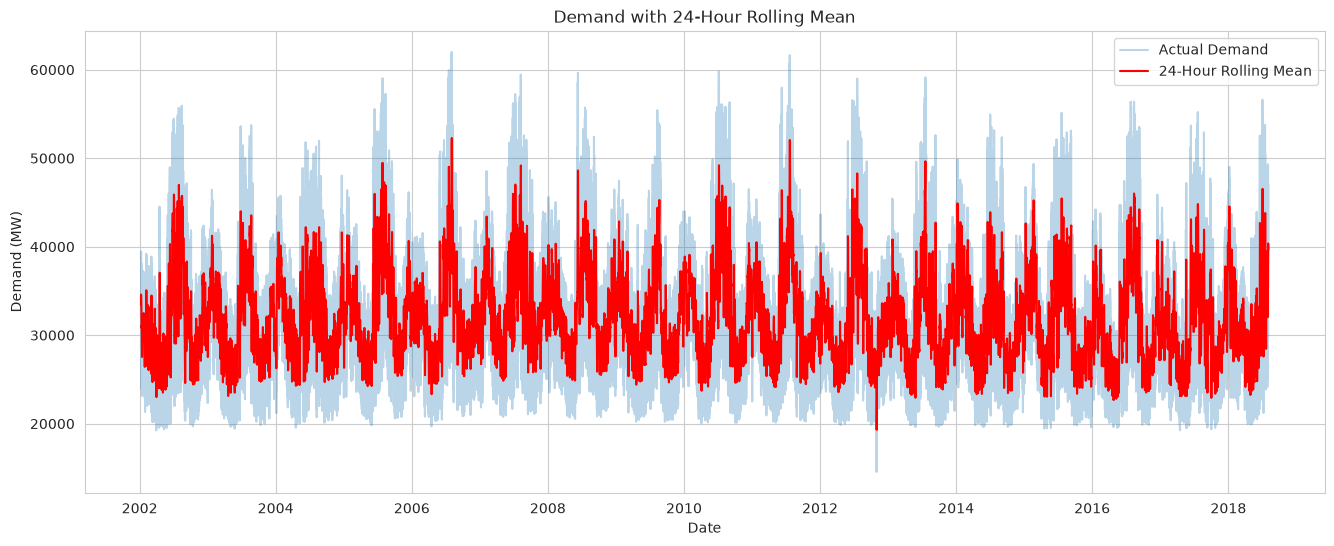

In [109]:
plt.figure(figsize=(16,6))

plt.plot(
    data.index,
    data["demand"],
    alpha=0.3,
    label="Actual Demand"
)

plt.plot(
    data.index,
    data["rolling_mean_24"],
    color="red",
    label="24-Hour Rolling Mean"
)

plt.title("Demand with 24-Hour Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")

plt.legend()
plt.show()

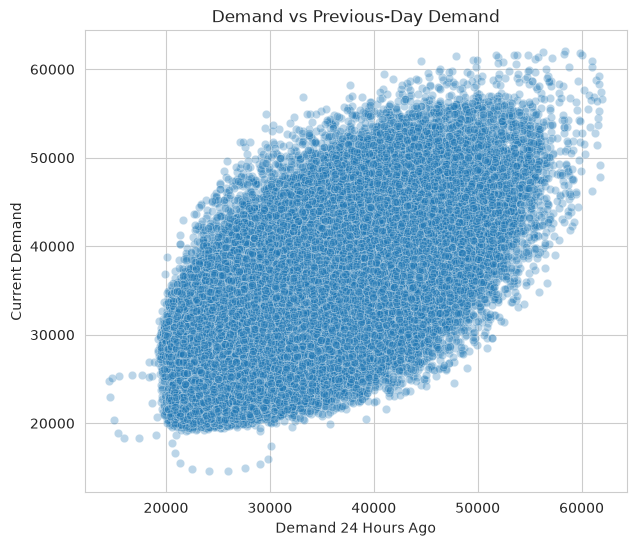

In [112]:
plt.figure(figsize=(7,6))

sns.scatterplot(
    x=data["lag_24"],
    y=data["demand"],
    alpha=0.3
)

plt.title("Demand vs Previous-Day Demand")
plt.xlabel("Demand 24 Hours Ago")
plt.ylabel("Current Demand")

plt.show()

In [113]:
print(
    data[["demand", "lag_1", "lag_24", "lag_48", "lag_168"]]
    .corr()["demand"]
    .sort_values(ascending=False)
)

demand     1.000000
lag_1      0.974793
lag_168    0.782470
lag_48     0.772853
lag_24     0.593049
Name: demand, dtype: float64


In [114]:
print(
    data[["demand", "lag_1", "lag_24", "lag_48", "lag_168"]]
    .corr()["demand"]
    .sort_values(ascending=False)
)

demand     1.000000
lag_1      0.974793
lag_168    0.782470
lag_48     0.772853
lag_24     0.593049
Name: demand, dtype: float64


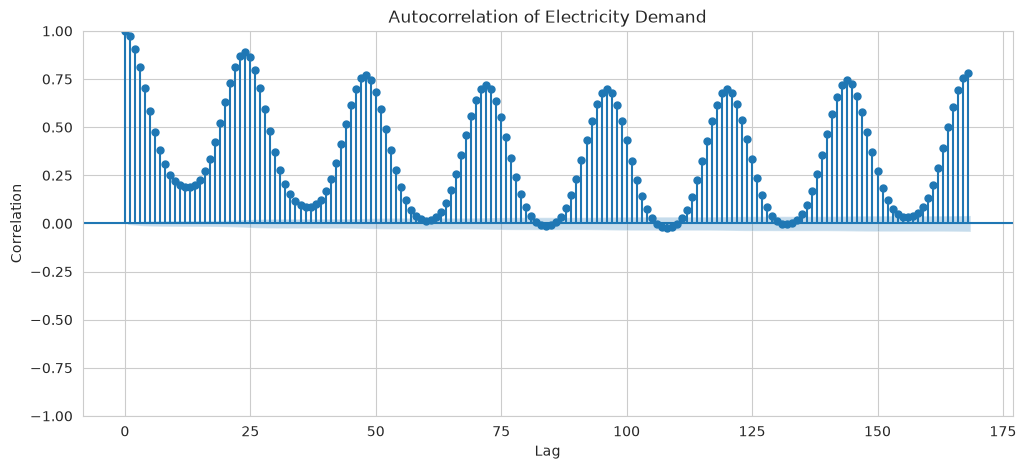

In [115]:
plt.figure(figsize=(12,5))

plot_acf(
    data["demand"],
    lags=168,
    ax=plt.gca()
)

plt.title("Autocorrelation of Electricity Demand")
plt.xlabel("Lag")
plt.ylabel("Correlation")

plt.show()

In [116]:
series = data["demand"].asfreq("h")

In [117]:
series = series.interpolate(method="time")

In [118]:
decomposition = seasonal_decompose(
    series,
    model="additive",
    period=24
)

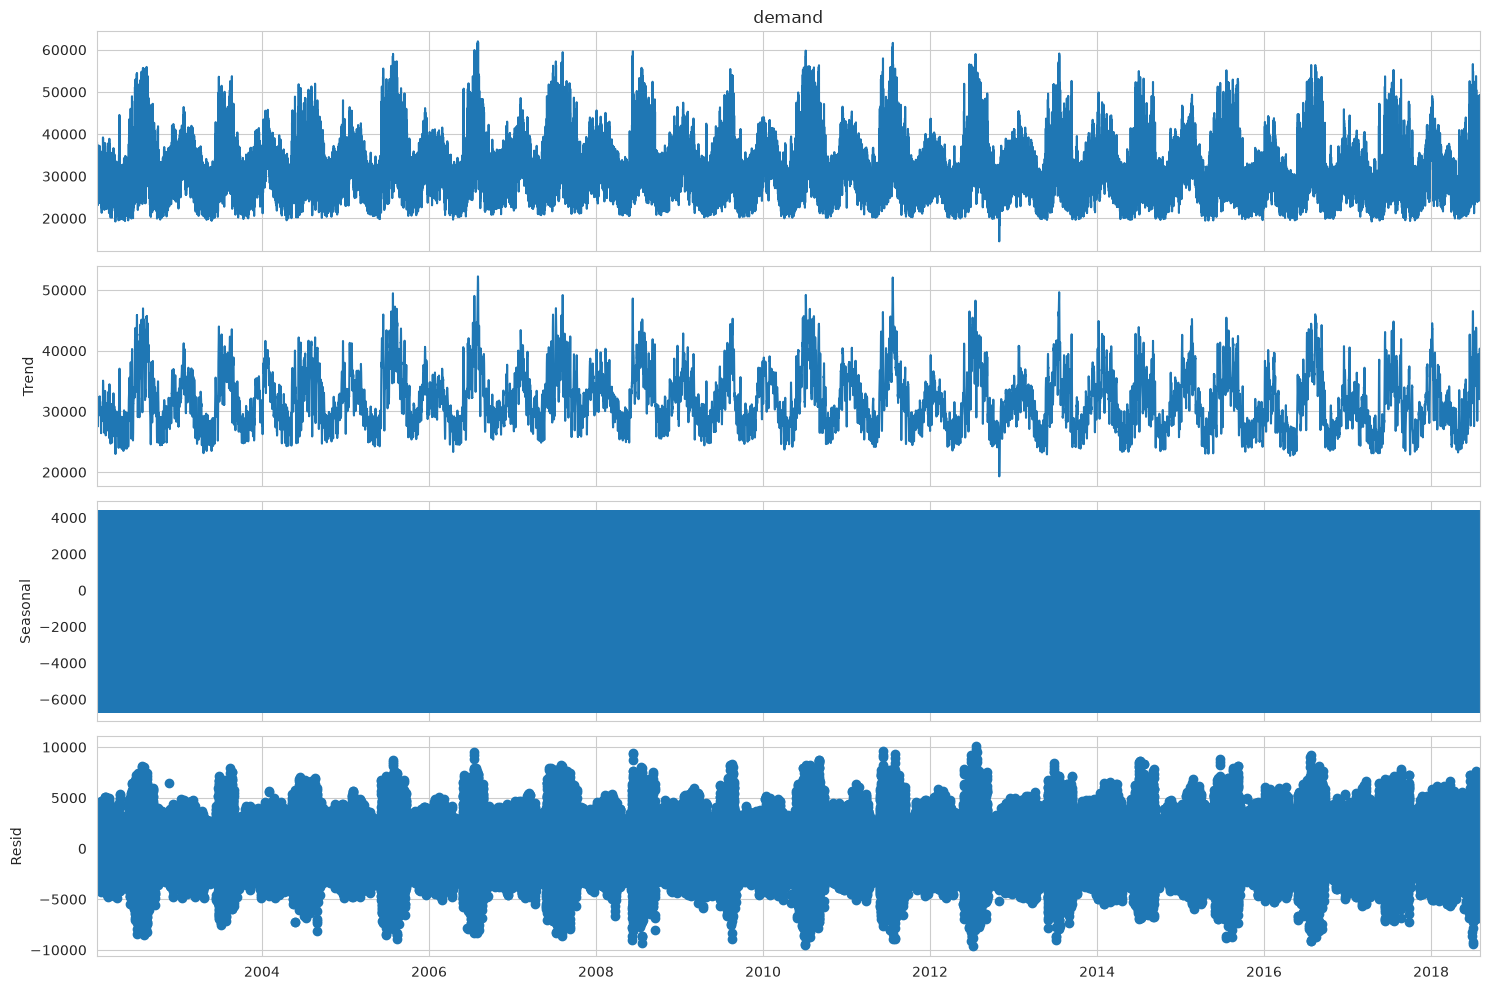

In [119]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.tight_layout()
plt.show()

# Phase-4 Baseline Forecasting Models

In [120]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [121]:
split_index = int(len(data) * 0.8)

train = data.iloc[:split_index].copy()
test = data.iloc[split_index:].copy()

print("Train:", train.shape)
print("Test :", test.shape)

Train: (116179, 17)
Test : (29045, 17)


In [122]:
y_test = test["demand"]

In [123]:
naive_pred = test["demand"].shift(1)

In [124]:
naive_pred.iloc[0] = train["demand"].iloc[-1]

In [125]:
print(naive_pred.head())

timestamp
2015-04-10 20:00:00    29352.0
2015-04-10 21:00:00    29685.0
2015-04-10 22:00:00    30185.0
2015-04-10 23:00:00    29187.0
2015-04-11 00:00:00    27327.0
Freq: h, Name: demand, dtype: float64


In [126]:
#Moving Average Forecast
combined = pd.concat([
    train["demand"],
    test["demand"]
])

In [127]:
moving_avg_pred = (
    combined.shift(1)
    .rolling(24)
    .mean()
    .loc[test.index]
)

In [128]:
previous_day_pred = combined.shift(24).loc[test.index]

In [132]:
previous_week_pred = combined.shift(168).loc[test.index]

In [133]:
#Create one prediction table
baseline_results = pd.DataFrame({
    "Actual": y_test,
    "Naive": naive_pred,
    "Moving_Average": moving_avg_pred,
    "Previous_Day": previous_day_pred,
    "Previous_Week": previous_week_pred
})

In [134]:
baseline_results.head()

,Actual,Naive,Moving_Average,Previous_Day,Previous_Week
timestamp,,,,,
2015-04-10 20:00:00,29685.0,29352.0,29758.375000,33843.0,28398.0
2015-04-10 21:00:00,30185.0,29685.0,29585.125000,33755.0,28452.0
2015-04-10 22:00:00,29187.0,30185.0,29436.375000,32363.0,27403.0
2015-04-10 23:00:00,27327.0,29187.0,29304.041667,30060.0,25818.0
2015-04-11 00:00:00,25390.0,27327.0,29190.166667,27846.0,24015.0


In [135]:
#evaluation report
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    r2 = r2_score(y_true, y_pred)

    bias = np.mean(y_pred - y_true)

    return mae, mse, rmse, mape, r2, bias

In [136]:
#Evaluate all baseline models
models = {
    "Naive": baseline_results["Naive"],
    "Moving Average": baseline_results["Moving_Average"],
    "Previous Day": baseline_results["Previous_Day"],
    "Previous Week": baseline_results["Previous_Week"]
}

In [137]:
results = []

for name, prediction in models.items():

    mae, mse, rmse, mape, r2, bias = evaluate_model(
        baseline_results["Actual"],
        prediction
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2,
        "Bias": bias
    })

In [138]:
baseline_comparison = pd.DataFrame(results)

baseline_comparison

,Model,MAE,MSE,RMSE,MAPE,R2,Bias
0,Naive,1069.993665,1.887443e+06,1373.842522,3.480642,0.955203,-0.211190
1,Moving Average,3643.048663,2.077076e+07,4557.494889,12.012786,0.507024,-5.107029
2,Previous Day,2184.268067,9.054211e+06,3009.021627,6.931439,0.785106,-8.068859
3,Previous Week,3391.865037,2.181175e+07,4670.305602,10.556023,0.482317,-49.052574


In [139]:
baseline_comparison.sort_values("RMSE")

,Model,MAE,MSE,RMSE,MAPE,R2,Bias
0,Naive,1069.993665,1.887443e+06,1373.842522,3.480642,0.955203,-0.211190
2,Previous Day,2184.268067,9.054211e+06,3009.021627,6.931439,0.785106,-8.068859
1,Moving Average,3643.048663,2.077076e+07,4557.494889,12.012786,0.507024,-5.107029
3,Previous Week,3391.865037,2.181175e+07,4670.305602,10.556023,0.482317,-49.052574


In [140]:
baseline_comparison.sort_values("MAE")

,Model,MAE,MSE,RMSE,MAPE,R2,Bias
0,Naive,1069.993665,1.887443e+06,1373.842522,3.480642,0.955203,-0.211190
2,Previous Day,2184.268067,9.054211e+06,3009.021627,6.931439,0.785106,-8.068859
3,Previous Week,3391.865037,2.181175e+07,4670.305602,10.556023,0.482317,-49.052574
1,Moving Average,3643.048663,2.077076e+07,4557.494889,12.012786,0.507024,-5.107029


In [141]:
plot_data = baseline_results.iloc[:24*7]

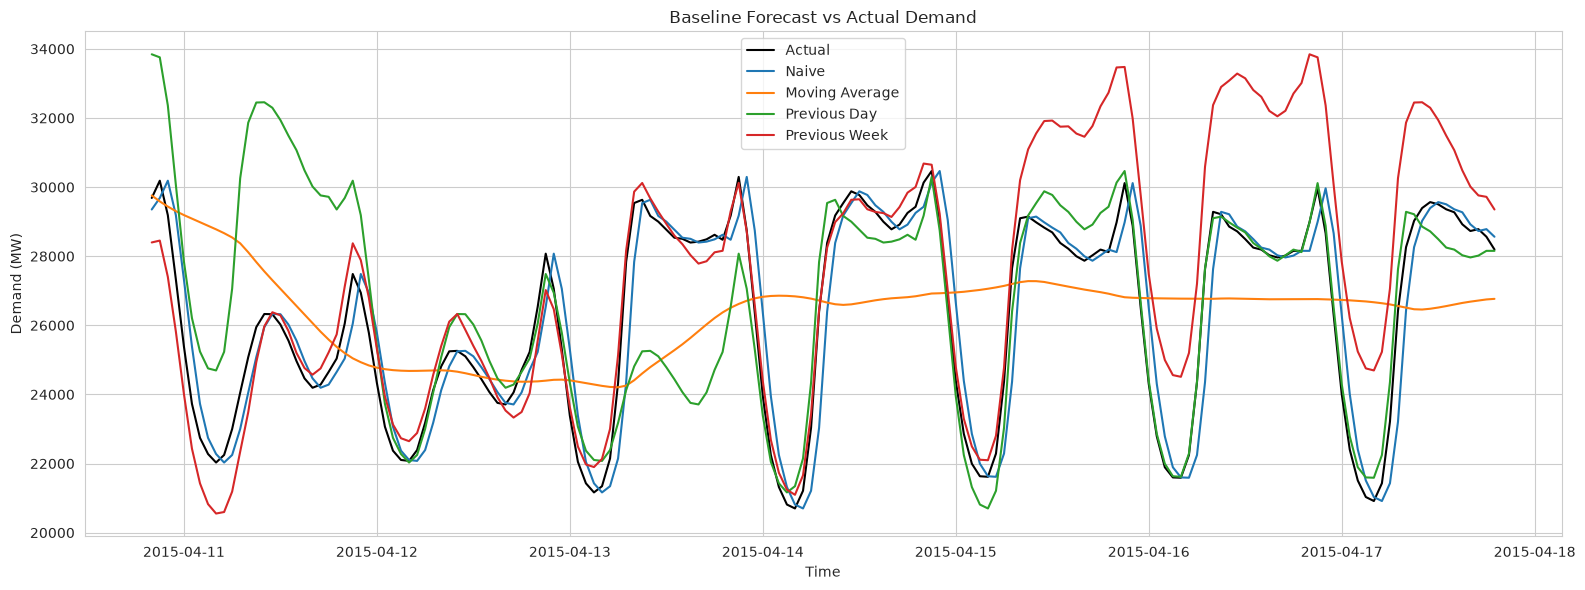

In [142]:
plt.figure(figsize=(16,6))

plt.plot(
    plot_data.index,
    plot_data["Actual"],
    label="Actual",
    color="black"
)

plt.plot(
    plot_data.index,
    plot_data["Naive"],
    label="Naive"
)

plt.plot(
    plot_data.index,
    plot_data["Moving_Average"],
    label="Moving Average"
)

plt.plot(
    plot_data.index,
    plot_data["Previous_Day"],
    label="Previous Day"
)

plt.plot(
    plot_data.index,
    plot_data["Previous_Week"],
    label="Previous Week"
)

plt.title("Baseline Forecast vs Actual Demand")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")

plt.legend()
plt.tight_layout()
plt.show()

In [143]:
baseline_comparison.to_csv(
    "baseline_model_comparison.csv",
    index=False
)